# 🚂 RailSafe — Exploration des données SNCF

**Objectif** : Explorer les données de régularité TGV, TER et Intercités pour comprendre les patterns de retards et préparer le feature engineering.

**Datasets :**
- `regularite_tgv.csv` — Régularité mensuelle TGV (2015-2024)
- `regularite_ter.csv` — Régularité mensuelle TER (2013-2024)
- `regularite_intercites.csv` — Régularité mensuelle Intercités (2014-2024)

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

RAW_DIR = Path('../data/raw')
print('✅ Imports OK')
print(f'📁 Data dir : {RAW_DIR.resolve()}')

✅ Imports OK
📁 Data dir : /Users/naim/Desktop/Ex_OC_nonlocalhost/railsafe/data/raw


## 2. Chargement des données

In [2]:
# Chargement TGV
tgv = pd.read_csv(RAW_DIR / 'regularite_tgv.csv', sep=';', encoding='utf-8')
tgv['type'] = 'TGV'
print(f'TGV        : {tgv.shape[0]:>6} lignes × {tgv.shape[1]} colonnes')

# Chargement TER
ter = pd.read_csv(RAW_DIR / 'regularite_ter.csv', sep=';', encoding='utf-8')
ter['type'] = 'TER'
print(f'TER        : {ter.shape[0]:>6} lignes × {ter.shape[1]} colonnes')

# Chargement Intercités
ic = pd.read_csv(RAW_DIR / 'regularite_intercites.csv', sep=';', encoding='utf-8')
ic['type'] = 'Intercités'
print(f'Intercités : {ic.shape[0]:>6} lignes × {ic.shape[1]} colonnes')

TGV        :  11834 lignes × 27 colonnes
TER        :   2282 lignes × 10 colonnes
Intercités :   5609 lignes × 10 colonnes


## 3. Exploration TGV

In [3]:
print('=== TGV — Colonnes ===')
for i, col in enumerate(tgv.columns):
    print(f'  {i:2d}. {col}')

=== TGV — Colonnes ===
   0. Date
   1. Service
   2. Gare de départ
   3. Gare d'arrivée
   4. Durée moyenne du trajet
   5. Nombre de circulations prévues
   6. Nombre de trains annulés
   7. Commentaire annulations
   8. Nombre de trains en retard au départ
   9. Retard moyen des trains en retard au départ
  10. Retard moyen de tous les trains au départ
  11. Commentaire retards au départ
  12. Nombre de trains en retard à l'arrivée
  13. Retard moyen des trains en retard à l'arrivée
  14. Retard moyen de tous les trains à l'arrivée
  15. Commentaire retards à l'arrivée
  16. Nombre trains en retard > 15min
  17. Retard moyen trains en retard > 15 (si liaison concurrencée par vol)
  18. Nombre trains en retard > 30min
  19. Nombre trains en retard > 60min
  20. Prct retard pour causes externes
  21. Prct retard pour cause infrastructure
  22. Prct retard pour cause gestion trafic
  23. Prct retard pour cause matériel roulant
  24. Prct retard pour cause gestion en gare et réutilisat

In [4]:
tgv.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",type
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.25,3.69,NaN,147,28.44,6.51,NaN,110,6.51,44,8,36.13,31.09,10.92,15.97,5.04,0.84,TGV
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.48,4.57,NaN,105,18.05,5.36,"Ce mois-ci, l'OD a été touchée par les inciden...",32,5.36,9,4,20.00,35.00,16.67,16.67,8.33,3.33,TGV
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.24,0.29,NaN,19,24.74,2.94,NaN,11,2.94,6,1,22.22,27.78,16.67,16.67,5.56,11.11,TGV
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.24,0.73,NaN,58,33.73,5.29,NaN,39,5.29,18,8,33.33,22.22,16.67,20.37,5.56,1.85,TGV
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.78,3.23,NaN,89,14.59,4.88,NaN,42,4.88,10,0,15.79,45.61,19.30,15.79,1.75,1.75,TGV


In [5]:
tgv.describe()

,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
count,11834.00,11834.00,11834.00,0.00,11834.00,11834.00,11834.00,0.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00,11834.00
mean,170.40,270.97,8.65,NaN,86.14,12.26,3.13,NaN,37.36,35.09,6.03,26.79,36.05,12.50,5.15,21.56,21.86,20.34,18.90,7.37,7.62
std,87.67,183.00,22.64,NaN,88.74,11.80,5.16,NaN,31.13,15.60,6.99,22.59,19.53,12.06,5.96,15.97,14.99,14.65,13.58,8.11,9.53
min,0.00,0.00,0.00,NaN,0.00,0.00,-229.27,NaN,0.00,-40.11,-472.64,0.00,-4.00,-44.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,99.00,150.00,0.00,NaN,21.00,6.14,1.20,NaN,15.00,25.70,3.39,11.00,27.80,4.00,1.00,10.53,11.87,10.34,10.00,0.00,0.00
50%,163.00,229.00,2.00,NaN,52.00,10.33,2.31,NaN,29.00,33.41,5.33,21.00,37.46,9.00,3.00,19.15,20.00,18.75,17.07,5.88,5.00
75%,222.75,359.00,7.00,NaN,126.00,15.70,3.93,NaN,51.00,42.39,8.07,36.00,46.86,17.00,7.00,30.00,29.63,28.57,25.42,11.11,11.11
max,786.00,1100.00,297.00,NaN,596.00,316.19,115.05,NaN,376.00,299.60,92.00,312.00,299.60,202.00,71.00,100.00,100.00,100.00,100.00,100.00,100.00


In [6]:
# Valeurs manquantes TGV
missing = tgv.isnull().sum()
missing_pct = (missing / len(tgv) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print('=== Valeurs manquantes TGV ===')
print(missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False))

=== Valeurs manquantes TGV ===
                                 missing    pct
Commentaire annulations            11834 100.00
Commentaire retards au départ      11834 100.00
Commentaire retards à l'arrivée    11136  94.10


## 4. Feature Engineering — Taux de retard

In [7]:
# Parsing de la date TGV
tgv['date'] = pd.to_datetime(tgv['Date'], format='%Y-%m')
tgv['annee'] = tgv['date'].dt.year
tgv['mois']  = tgv['date'].dt.month

# Colonnes numériques clés
col_circu    = 'Nombre de circulations prévues'
col_retard   = "Nombre de trains en retard à l'arrivée"
col_annule   = 'Nombre de trains annulés'
col_cause_infra  = 'Prct retard pour cause infrastructure'
col_cause_mat    = 'Prct retard pour cause matériel roulant'
col_cause_ext    = 'Prct retard pour causes externes'
col_cause_trafic = 'Prct retard pour cause gestion trafic'

# Taux de retard = retards / circulations prévues
tgv['taux_retard'] = tgv[col_retard] / tgv[col_circu]
tgv['taux_annulation'] = tgv[col_annule] / tgv[col_circu]

# Cible binaire : retard élevé si taux > 75e percentile
seuil = tgv['taux_retard'].quantile(0.75)
tgv['retard_eleve'] = (tgv['taux_retard'] > seuil).astype(int)

print(f'Seuil retard élevé (75e percentile) : {seuil:.3f} ({seuil*100:.1f}%)')
print(f'Classe 0 (normal)  : {(tgv["retard_eleve"]==0).sum()} lignes')
print(f'Classe 1 (élevé)   : {(tgv["retard_eleve"]==1).sum()} lignes')
print(f'\nTaux de retard moyen : {tgv["taux_retard"].mean()*100:.1f}%')
print(f'Taux de retard max   : {tgv["taux_retard"].max()*100:.1f}%')

Seuil retard élevé (75e percentile) : 0.174 (17.4%)
Classe 0 (normal)  : 8894 lignes
Classe 1 (élevé)   : 2940 lignes

Taux de retard moyen : 13.9%
Taux de retard max   : 100.0%


## 5. Visualisations

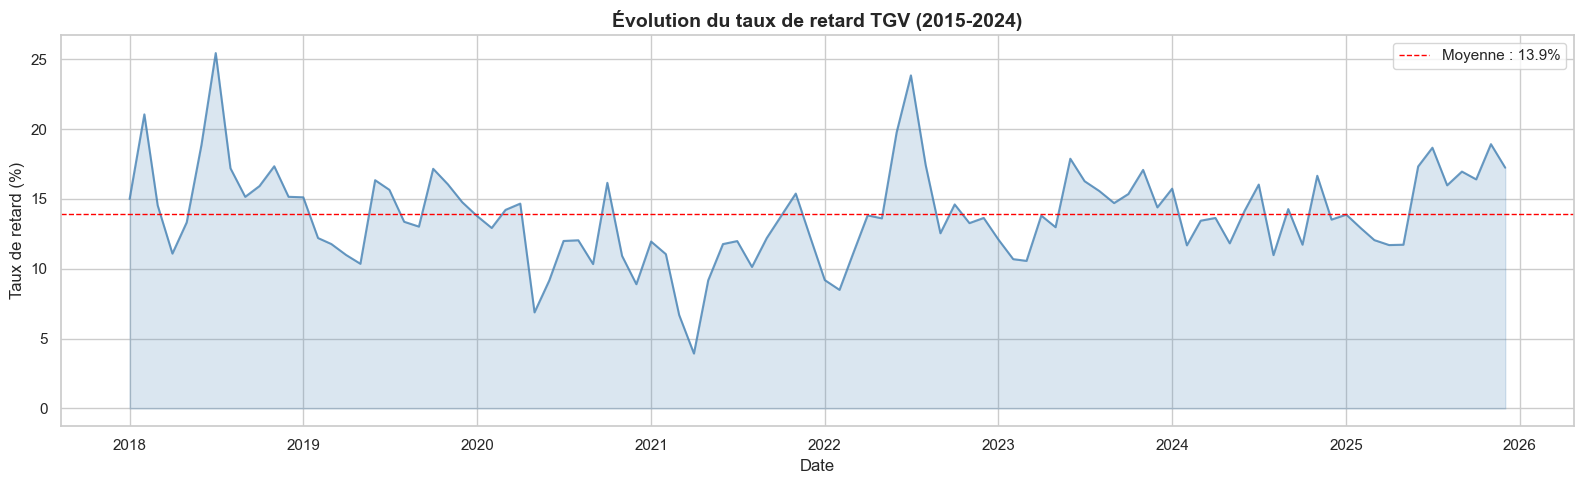

✅ Sauvegardé : data/viz_taux_retard_tgv.png


In [8]:
# Evolution du taux de retard TGV dans le temps
tgv_monthly = tgv.groupby('date')['taux_retard'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(tgv_monthly['date'], tgv_monthly['taux_retard'] * 100,
        color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(tgv_monthly['date'], tgv_monthly['taux_retard'] * 100,
                alpha=0.2, color='steelblue')
ax.axhline(tgv['taux_retard'].mean() * 100, color='red',
           linestyle='--', linewidth=1, label=f'Moyenne : {tgv["taux_retard"].mean()*100:.1f}%')
ax.set_title('Évolution du taux de retard TGV (2015-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Taux de retard (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/viz_taux_retard_tgv.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : data/viz_taux_retard_tgv.png')

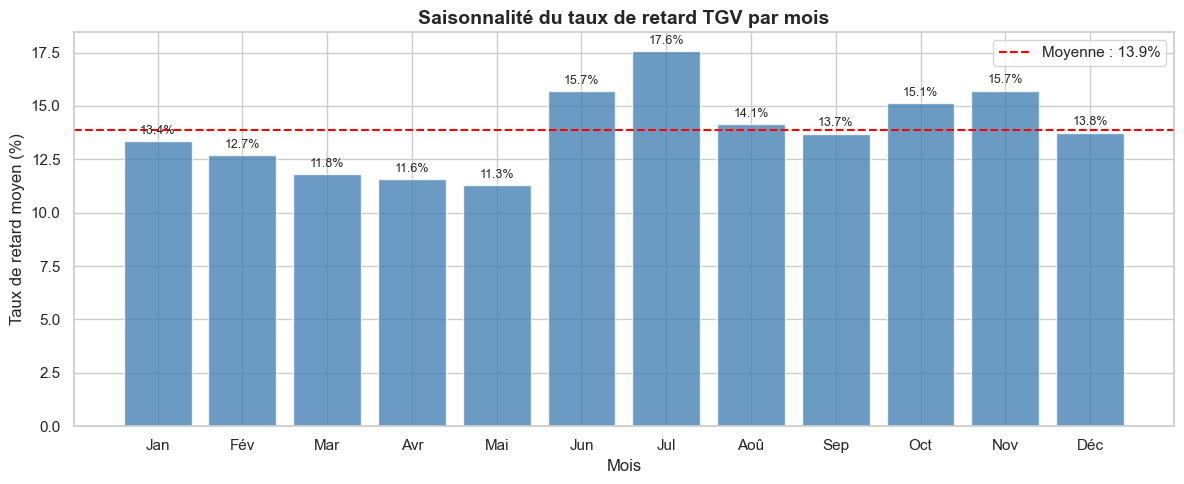

In [9]:
# Saisonnalité — taux de retard par mois
monthly_avg = tgv.groupby('mois')['taux_retard'].mean() * 100
mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mois_labels, monthly_avg.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(monthly_avg.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Moyenne : {monthly_avg.mean():.1f}%')
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Saisonnalité du taux de retard TGV par mois', fontsize=14, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux de retard moyen (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/viz_saisonnalite_tgv.png', dpi=120, bbox_inches='tight')
plt.show()

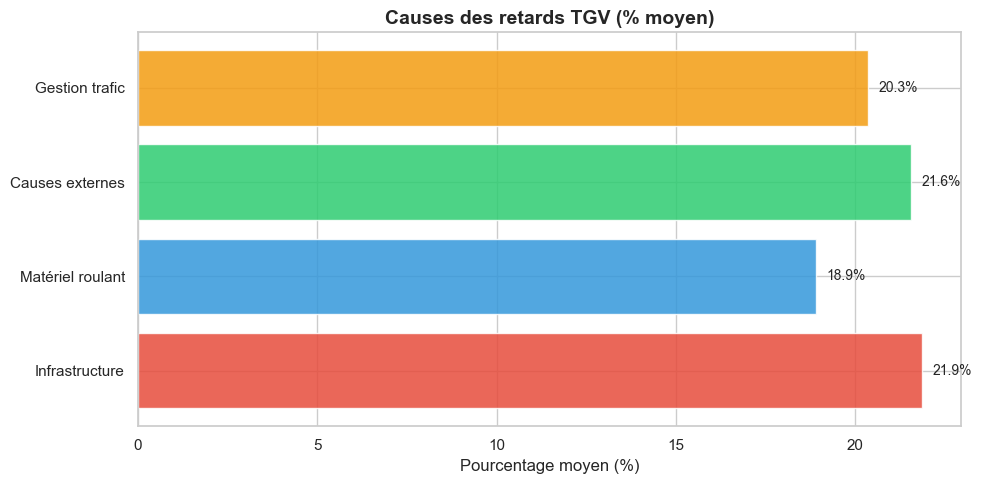

In [10]:
# Causes des retards TGV
causes_cols = {
    'Infrastructure'  : col_cause_infra,
    'Matériel roulant': col_cause_mat,
    'Causes externes' : col_cause_ext,
    'Gestion trafic'  : col_cause_trafic,
}
causes_means = {k: tgv[v].mean() for k, v in causes_cols.items() if v in tgv.columns}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax.barh(list(causes_means.keys()), list(causes_means.values()),
               color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, causes_means.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Causes des retards TGV (% moyen)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pourcentage moyen (%)')
plt.tight_layout()
plt.savefig('../data/viz_causes_retards_tgv.png', dpi=120, bbox_inches='tight')
plt.show()

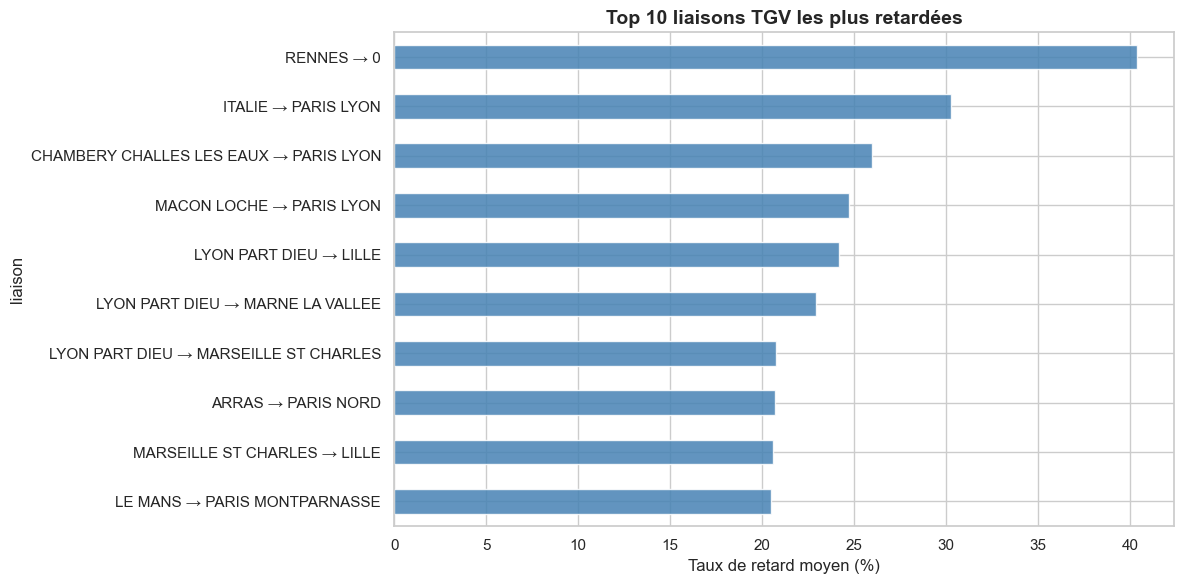

In [11]:
# Top 10 liaisons TGV les plus retardées
if 'Gare de départ' in tgv.columns and "Gare d'arrivée" in tgv.columns:
    tgv['liaison'] = tgv['Gare de départ'] + ' → ' + tgv["Gare d'arrivée"]
    top_retards = (tgv.groupby('liaison')['taux_retard']
                     .mean()
                     .sort_values(ascending=False)
                     .head(10) * 100)

    fig, ax = plt.subplots(figsize=(12, 6))
    top_retards.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
    ax.set_title('Top 10 liaisons TGV les plus retardées', fontsize=14, fontweight='bold')
    ax.set_xlabel('Taux de retard moyen (%)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('../data/viz_top_liaisons_tgv.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. Exploration TER

In [12]:
print('=== TER — Colonnes ===')
for i, col in enumerate(ter.columns):
    print(f'  {i:2d}. {col}')
ter.head()

=== TER — Colonnes ===
   0. Date
   1. Région
   2. Nombre de trains programmés
   3. Nombre de trains ayant circulé
   4. Nombre de trains annulés
   5. Nombre de trains en retard à l'arrivée
   6. Taux de régularité
   7. Nombre de trains à l'heure pour un train en retard à l'arrivée
   8. Commentaires
   9. type


,Date,Région,Nombre de trains programmés,Nombre de trains ayant circulé,Nombre de trains annulés,Nombre de trains en retard à l'arrivée,Taux de régularité,Nombre de trains à l'heure pour un train en retard à l'arrivée,Commentaires,type
0,2013-01,Aquitaine,8099.00,8014.00,85.00,731.00,90.88,9.96,Intempéries à partir du 20 janvier.,TER
1,2013-01,Auvergne,5785.00,5732.00,53.00,431.00,92.48,12.30,Conditions météos défavorables.,TER
2,2013-01,Champagne Ardenne,6648.00,6595.00,53.00,334.00,94.94,18.75,Conditions météorologiques dégradées du 15 au ...,TER
3,2013-01,Limousin,3817.00,3770.00,47.00,210.00,94.43,16.95,NaN,TER
4,2013-01,Midi Pyrénées,8208.00,7941.00,267.00,903.00,88.63,7.79,NaN,TER


In [13]:
# Parsing date TER
ter['date'] = pd.to_datetime(ter['Date'], format='%Y-%m')
ter['annee'] = ter['date'].dt.year
ter['mois']  = ter['date'].dt.month

col_ter_prog   = 'Nombre de trains programmés'
col_ter_retard = "Nombre de trains en retard à l'arrivée"
col_ter_annule = 'Nombre de trains annulés'

ter['taux_retard']    = ter[col_ter_retard] / ter[col_ter_prog]
ter['taux_annulation'] = ter[col_ter_annule] / ter[col_ter_prog]

print(f'Taux de retard moyen TER : {ter["taux_retard"].mean()*100:.1f}%')
print(f'Régions : {ter["Région"].nunique()}')
print(ter['Région'].value_counts().head(10))

Taux de retard moyen TER : 8.3%
Régions : 31
Région
Pays-de-la-Loire              157
Provence Alpes Côte d'Azur    157
Bretagne                      157
Grand Est                     109
Normandie                      97
Auvergne-Rhône-Alpes           97
Hauts-de-France                97
Bourgogne-Franche-Comté        97
Centre                         92
Aquitaine                      92
Name: count, dtype: int64


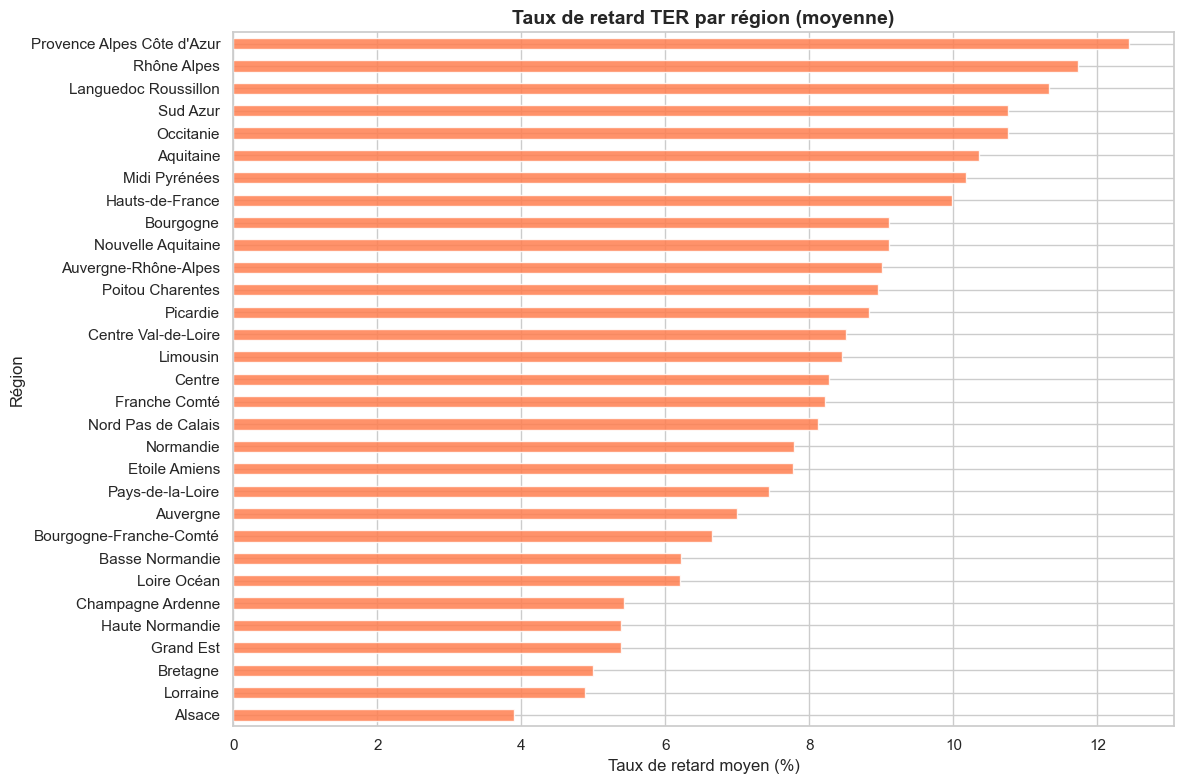

In [14]:
# Taux de retard TER par région
ter_region = (ter.groupby('Région')['taux_retard']
                 .mean()
                 .sort_values(ascending=False) * 100)

fig, ax = plt.subplots(figsize=(12, 8))
ter_region.plot(kind='barh', ax=ax, color='coral', alpha=0.85)
ax.set_title('Taux de retard TER par région (moyenne)', fontsize=14, fontweight='bold')
ax.set_xlabel('Taux de retard moyen (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/viz_retard_ter_region.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Corrélations TGV

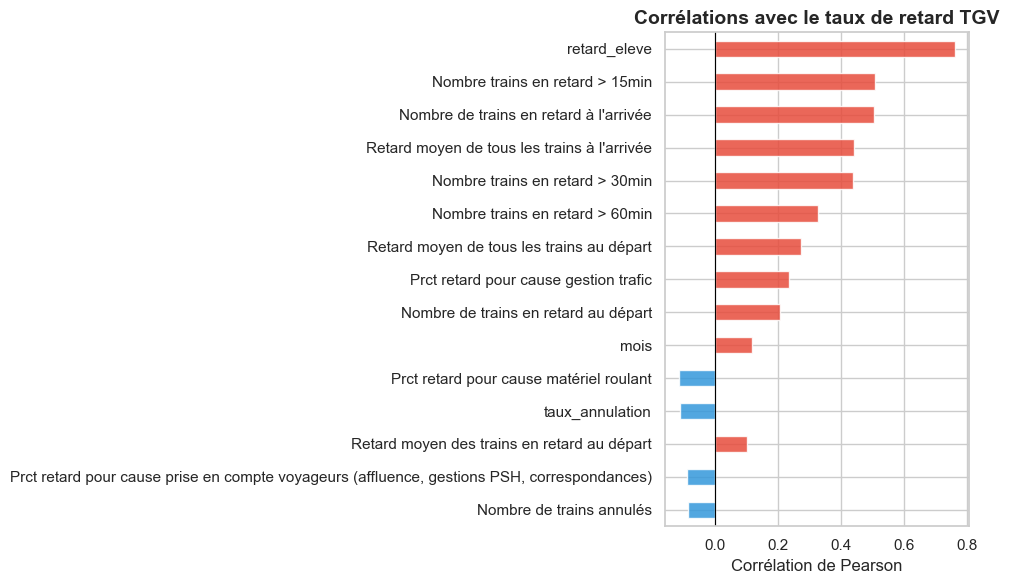


Top corrélations positives (→ augmentent les retards) :
retard_eleve                                  0.76
Nombre trains en retard > 15min               0.51
Nombre de trains en retard à l'arrivée        0.51
Retard moyen de tous les trains à l'arrivée   0.44
Nombre trains en retard > 30min               0.44
Name: taux_retard, dtype: float64

Top corrélations négatives (→ réduisent les retards) :
Prct retard pour cause matériel roulant                                                       -0.11
taux_annulation                                                                               -0.11
Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)   -0.09
Nombre de trains annulés                                                                      -0.08
Name: taux_retard, dtype: float64


In [15]:
# Matrice de corrélation sur les colonnes numériques TGV
num_cols = tgv.select_dtypes(include=[np.number]).columns.tolist()
corr = tgv[num_cols].corr()

# Focus sur la corrélation avec taux_retard
corr_target = corr['taux_retard'].drop('taux_retard').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélations avec le taux de retard TGV', fontsize=14, fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/viz_correlations_tgv.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop corrélations positives (→ augmentent les retards) :')
print(corr_target[corr_target > 0].head(5))
print('\nTop corrélations négatives (→ réduisent les retards) :')
print(corr_target[corr_target < 0].head(5))

## 8. Résumé & Conclusions

In [16]:
print('=' * 60)
print('📊 RÉSUMÉ EDA — RailSafe')
print('=' * 60)

print(f"""
📁 Données disponibles :
  - TGV        : {tgv.shape[0]:,} lignes, {tgv['date'].min().year}-{tgv['date'].max().year}
  - TER        : {ter.shape[0]:,} lignes, {ter['date'].min().year}-{ter['date'].max().year}
  - Intercités : {ic.shape[0]:,} lignes

🎯 Variable cible :
  - taux_retard (continu) → régression XGBoost
  - retard_eleve (binaire, seuil 75e pct) → classification XGBoost

📌 Features principales identifiées :
  - mois (saisonnalité)
  - annee (tendance)
  - taux_annulation (proxy fiabilité)
  - causes retards (infra, matériel, externe, trafic)
  - type de service (TGV/TER/IC)
  - liaison (gare départ → arrivée)

➡️  Prochaine étape : notebooks/02_feature_engineering.ipynb
""")

📊 RÉSUMÉ EDA — RailSafe

📁 Données disponibles :
  - TGV        : 11,834 lignes, 2018-2025
  - TER        : 2,282 lignes, 2013-2026
  - Intercités : 5,609 lignes

🎯 Variable cible :
  - taux_retard (continu) → régression XGBoost
  - retard_eleve (binaire, seuil 75e pct) → classification XGBoost

📌 Features principales identifiées :
  - mois (saisonnalité)
  - annee (tendance)
  - taux_annulation (proxy fiabilité)
  - causes retards (infra, matériel, externe, trafic)
  - type de service (TGV/TER/IC)
  - liaison (gare départ → arrivée)

➡️  Prochaine étape : notebooks/02_feature_engineering.ipynb

